# 10. Causal Inference with LLM and AI Systems

LLM and AI systems are not only prediction systems. In production, they are interventions.

They change what users see, what workers do, which tickets are escalated, which documents are retrieved, which messages are sent, which cases are reviewed, and what data will be generated next. That makes causal inference central to AI deployment.

This notebook treats AI systems as causal objects:

- the model or agent workflow is a treatment,
- usage and retrieval quality are post-treatment variables,
- LLM judges are measurement systems,
- routing policies create confounding,
- bandit logs require counterfactual evaluation,
- feedback loops change future data,
- deployment decisions require causal estimands, not only benchmark scores.

The goal is to connect modern AI practice with the causal design tools from the earlier lectures.


## Learning Goals

By the end of this notebook, you should be able to:

- Define causal estimands for LLM and AI product deployments.
- Distinguish benchmark improvement from real-world causal impact.
- Estimate intent-to-treat effects for randomized AI features.
- Explain why usage, retrieval success, and human handoff are often post-treatment variables.
- Diagnose LLM-as-judge measurement bias and calibrate with human audit data.
- Use inverse propensity and doubly robust estimators for logged AI routing policies.
- Recognize feedback loops and interference in AI systems.
- Design an AI experiment with guardrails, power, triggering, and monitoring.
- Write an industry causal memo for an AI/LLMOps deployment.


## 1. Setup

The examples use simulated data and standard Python packages. No LLM API calls are required.


In [1]:
# Import the analysis, modeling, and plotting tools used throughout this notebook.
import warnings
warnings.filterwarnings("ignore")

from graphviz import Digraph
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.special import expit
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


def regression_effect(model, term):
    """Compute regression effect for the causal inference with llm ai systems example.
    
    Inputs:
    - `model`: fitted statistical or machine-learning model whose coefficients or predictions are being used.
    - `term`: coefficient name whose estimate and uncertainty should be extracted.
    Returns: an effect-estimate summary for the causal comparison in the section."""
    estimate = model.params[term]
    se = model.bse[term]
    return pd.Series(
        {
            "estimate": estimate,
            "std_error": se,
            "ci_lower": estimate - 1.96 * se,
            "ci_upper": estimate + 1.96 * se,
            "p_value": model.pvalues[term],
        }
    )


def mean_difference(df, outcome, treatment):
    """Compute mean difference for the causal inference with llm ai systems example.
    
    Inputs:
    - `df`: pandas DataFrame containing the observed or simulated data used by this estimator, plot, or diagnostic.
    - `outcome`: name of the observed outcome column whose causal contrast is being estimated.
    - `treatment`: name of the treatment-assignment column, usually coded as treated versus control.
    Returns: a treatment-control contrast with estimate and uncertainty fields."""
    treated = df.loc[df[treatment] == 1, outcome]
    control = df.loc[df[treatment] == 0, outcome]
    estimate = treated.mean() - control.mean()
    se = np.sqrt(treated.var(ddof=1) / treated.size + control.var(ddof=1) / control.size)
    return pd.Series(
        {
            "estimate": estimate,
            "std_error": se,
            "ci_lower": estimate - 1.96 * se,
            "ci_upper": estimate + 1.96 * se,
            "p_value": np.nan,
        }
    )


def plot_coef_table(table, title, xlabel, reference=0, figsize=(8.5, 4.5)):
    """Plot the coef table display.
    
    Inputs:
    - `table`: estimate table with columns such as estimate, standard error, and confidence limits.
    - `title`: plot or graph title displayed above the figure.
    - `xlabel`: x-axis label used in the estimate plot.
    - `reference`: reference value shown as a vertical line, often the true or benchmark effect.
    - `figsize`: Matplotlib figure size passed to the plotting function.
    Returns: a Matplotlib figure or axes object that visualizes the causal estimates."""
    plot_df = table.sort_values("estimate")
    fig, ax = plt.subplots(figsize=figsize)
    ax.errorbar(
        x=plot_df["estimate"],
        y=plot_df.index,
        xerr=[
            plot_df["estimate"] - plot_df["ci_lower"],
            plot_df["ci_upper"] - plot_df["estimate"],
        ],
        fmt="o",
        color="#2b8cbe",
        ecolor="#a6bddb",
        elinewidth=3,
        capsize=4,
    )
    ax.axvline(reference, color="#444444", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    plt.tight_layout()
    return fig, ax


### Dataset and Experiment Setup

This notebook simulates LLM and AI deployments as causal interventions. The units include support cases, users, prompts, tasks, routed requests, and time periods after launch. Treatments include assistant access, model variant, retrieval configuration, LLM-as-judge use, routing policy, and feedback-loop exposure. Outcomes include resolution, latency, cost, quality, risk, guardrail failures, and reward under logged policies.

The examples are simulated because AI systems create counterfactual and logging problems that are hard to observe from production data alone. We usually do not know what would have happened if a request had been routed to a different model, if retrieval had been disabled, or if a different guardrail policy had been used. The generated data includes assignment, adoption, logging propensities, hidden task difficulty, judge bias, and policy values. This lets the notebook teach why benchmark gains are not the same as causal product impact and why AI launches need causal monitoring.


## 2. AI Systems as Treatments

A deployed AI system can be a treatment at many levels:

- model version,
- prompt template,
- retrieval configuration,
- agent tool policy,
- escalation rule,
- guardrail,
- user interface,
- human-in-the-loop workflow,
- model routing policy.

The causal estimand must name the intervention. For example:

$$
E[Y(\text{RAG assistant}) - Y(\text{standard search})]
$$

is different from:

$$
E[Y(\text{agent with tool use}) - Y(\text{chat-only assistant})]
$$

and both are different from an offline benchmark difference.


### Mathematical Core: AI Assignment, Usage, and Logged Policies

AI deployments often involve assignment, actual usage, and downstream behavior. Let $Z_i$ be assignment to AI access, $D_i$ be actual AI use, and $Y_i$ be a business or quality outcome. The intention-to-treat effect is:

$$
ITT = E[Y\mid Z=1]-E[Y\mid Z=0].
$$

If assignment changes usage, the complier-style effect can be estimated with a Wald ratio:

$$
TOT_{IV}=\frac{E[Y\mid Z=1]-E[Y\mid Z=0]}{E[D\mid Z=1]-E[D\mid Z=0]}.
$$

For model routing, let $A_i$ be the action chosen by a logging policy $b(a\mid X_i)$ and let $\pi(a\mid X_i)$ be a new policy. The value of the new policy is:

$$
V(\pi)=E\left[\sum_{a} \pi(a\mid X_i)Y_i(a)\right].
$$

An inverse-propensity estimator uses logged data as:

$$
\hat V_{IPS}(\pi)=\frac{1}{n}\sum_{i=1}^{n}\frac{\pi(A_i\mid X_i)}{b(A_i\mid X_i)}Y_i.
$$

The same distinction appears throughout AI evaluation. Randomized assignment answers deployment questions. Actual usage is often post-treatment. Logged routing requires support and reliable propensities. LLM-as-judge scores are measurements, so they also need calibration and validation.


| intervention | example | causal estimand |
|---|---|---|
| Model version | Model A vs Model B in support assistant | Effect on resolution, cost, escalation, customer satisfaction |
| RAG configuration | Top-5 vs top-20 retrieval with reranking | Effect on factuality, latency, completion, trust |
| Agent workflow | Tool-calling agent vs single-turn answer | Effect on task success and operational risk |
| Guardrail | Strict refusal policy vs contextual refusal policy | Effect on unsafe output and false refusals |
| Routing policy | Small model, large model, or human escalation | Policy value under success, cost, and SLA constraints |
| UI integration | AI draft shown inline vs separate assistant panel | Effect on adoption, edits, time-to-completion, quality |


## 3. A Causal DAG for AI Deployment

The structure below is typical:

- user or task difficulty affects both adoption and outcomes,
- random assignment affects access to the AI system,
- actual usage is post-assignment,
- retrieval quality and response quality are mediators,
- measurement can be human, behavioral, or LLM-based,
- future data can be affected by current model decisions.


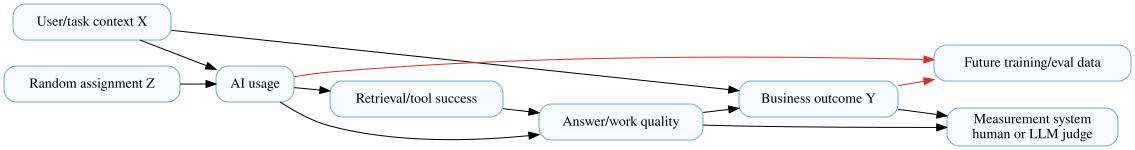

In [3]:
dot = Digraph("ai_deployment_dag", graph_attr={"rankdir": "LR"})
dot.attr("node", shape="box", style="rounded,filled", fillcolor="#f7fbff", color="#6baed6")

dot.node("X", "User/task context X")
dot.node("Z", "Random assignment Z")
dot.node("Use", "AI usage")
dot.node("R", "Retrieval/tool success")
dot.node("Q", "Answer/work quality")
dot.node("Y", "Business outcome Y")
dot.node("M", "Measurement system\nhuman or LLM judge")
dot.node("Future", "Future training/eval data")

dot.edge("X", "Use")
dot.edge("X", "Y")
dot.edge("Z", "Use")
dot.edge("Use", "R")
dot.edge("R", "Q")
dot.edge("Use", "Q")
dot.edge("Q", "Y")
dot.edge("Y", "M")
dot.edge("Q", "M")
dot.edge("Y", "Future", color="#de2d26")
dot.edge("Use", "Future", color="#de2d26")

dot


A key lesson:

> Do not condition on post-treatment variables unless the estimand explicitly requires it.

Usage, retrieval success, answer quality, and human handoff may all be affected by assignment. They can help diagnose mechanisms, but conditioning on them can change the estimand or introduce bias.


## 4. Simulation 1: Randomized AI Assistant Rollout

Imagine a support organization testing an AI drafting assistant for agents.

Random assignment:

$$
Z_i \in \{0,1\}
$$

Business outcome:

$$
Y_i = \text{resolved in first contact}
$$

Some assigned agents do not use the assistant. That creates a distinction between:

- **Intent-to-treat (ITT)**: effect of being assigned access.
- **Treatment-on-the-treated (TOT)**: effect of actual usage for compliers, often estimated using assignment as an instrument.
- **As-treated comparison**: usually biased because usage is selected.


In [4]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
rng = np.random.default_rng(5010)
n = 12_000

support = pd.DataFrame(
    {
        "agent_experience": rng.normal(0, 1, size=n),
        "case_complexity": rng.normal(0, 1, size=n),
        "pre_period_resolution": rng.normal(0, 1, size=n),
    }
)

support["Z_assigned_ai"] = rng.binomial(1, 0.5, size=n)

support["uses_ai"] = rng.binomial(
    1,
    expit(
        -0.6
        + 1.8 * support["Z_assigned_ai"]
        + 0.5 * support["agent_experience"]
        - 0.8 * support["case_complexity"]
    ),
    size=n,
)

true_usage_effect = 0.09
support["p_resolution"] = expit(
    -0.1
    + true_usage_effect * 4.0 * support["uses_ai"]
    + 0.55 * support["agent_experience"]
    - 0.75 * support["case_complexity"]
    + 0.25 * support["pre_period_resolution"]
)
support["resolved"] = rng.binomial(1, support["p_resolution"], size=n)
support["handle_minutes"] = (
    24
    - 3.2 * support["uses_ai"]
    - 2.5 * support["agent_experience"]
    + 5.0 * support["case_complexity"]
    + rng.normal(0, 6, size=n)
)

assignment_balance = support.groupby("Z_assigned_ai")[["agent_experience", "case_complexity", "pre_period_resolution"]].mean()
assignment_balance


,agent_experience,case_complexity,pre_period_resolution
Z_assigned_ai,,,
0,-0.0060,-0.0044,-0.0039
1,0.0160,-0.0129,0.0017


At this point, ask what the result lets us defend. AI evaluations depend on treatment definition, logging, measurement quality, and downstream behavior.

In [5]:
# Fit the models for this section and assemble the estimates used in the discussion.
itt_resolution = mean_difference(support, "resolved", "Z_assigned_ai")
itt_minutes = mean_difference(support, "handle_minutes", "Z_assigned_ai")

as_treated_resolution = mean_difference(support, "resolved", "uses_ai")

first_stage = mean_difference(support, "uses_ai", "Z_assigned_ai")["estimate"]
wald_tot = itt_resolution["estimate"] / first_stage

cuped_model = smf.ols(
    "resolved ~ Z_assigned_ai + pre_period_resolution + agent_experience + case_complexity",
    data=support,
).fit()

rollout_results = pd.DataFrame(
    {
        "ITT: assigned AI -> resolution": itt_resolution,
        "As-treated: used AI -> resolution": as_treated_resolution,
        "Wald TOT: assignment as instrument": pd.Series(
            {
                "estimate": wald_tot,
                "std_error": np.nan,
                "ci_lower": np.nan,
                "ci_upper": np.nan,
                "p_value": np.nan,
            }
        ),
        "CUPED/regression adjusted ITT": regression_effect(cuped_model, "Z_assigned_ai"),
    }
).T

pd.Series(
    {
        "AI usage rate if assigned control": support.loc[support["Z_assigned_ai"] == 0, "uses_ai"].mean(),
        "AI usage rate if assigned treatment": support.loc[support["Z_assigned_ai"] == 1, "uses_ai"].mean(),
        "first_stage_usage_difference": first_stage,
    }
), rollout_results


(AI usage rate if assigned control     0.3692
 AI usage rate if assigned treatment   0.7327
 first_stage_usage_difference          0.3635
 dtype: float64,
                                     estimate  std_error  ci_lower  ci_upper  \
 ITT: assigned AI -> resolution        0.0495     0.0091    0.0317    0.0674   
 As-treated: used AI -> resolution     0.2284     0.0089    0.2109    0.2459   
 Wald TOT: assignment as instrument    0.1362        NaN       NaN       NaN   
 CUPED/regression adjusted ITT         0.0453     0.0083    0.0291    0.0616   
 
                                     p_value  
 ITT: assigned AI -> resolution          NaN  
 As-treated: used AI -> resolution       NaN  
 Wald TOT: assignment as instrument      NaN  
 CUPED/regression adjusted ITT        0.0000  )

For a decision maker, the practical meaning matters most. For AI systems, model output is only one layer of the causal system. Usage, routing, and measurement matter too.

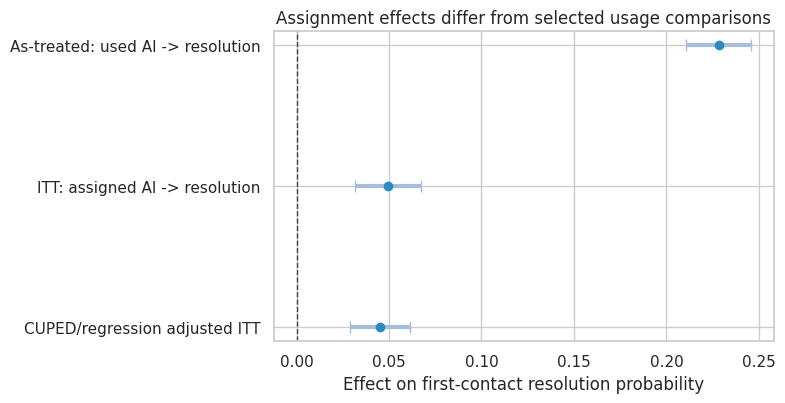

In [6]:
plot_coef_table(
    rollout_results.drop(index="Wald TOT: assignment as instrument"),
    title="Assignment effects differ from selected usage comparisons",
    xlabel="Effect on first-contact resolution probability",
    reference=0,
    figsize=(8, 4.2),
)
plt.show()


### Interpretation

The ITT estimate answers the deployment question:

> What is the effect of assigning access to the AI assistant?

The as-treated comparison is not a randomized comparison. Agents who use AI differ from those who do not. In this simulation, usage is more common among experienced agents and easier cases, so the as-treated comparison overstates the effect of actual usage.

The Wald estimate uses assignment as an instrument for usage. It targets a complier effect under additional assumptions: assignment affects the outcome only through usage, no defiers, and valid exclusion restrictions.


## 5. Multi-Arm AI System Experiments

AI deployments often compare several versions:

- baseline workflow,
- plain chat assistant,
- RAG assistant,
- tool-using agent,
- human escalation policy.

The outcome is rarely one metric. A better version may improve success but cost more or increase latency. A causal analysis should estimate the tradeoff surface.


In [7]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
rng = np.random.default_rng(5011)
n = 16_000
variants = ["baseline", "chat", "rag", "agent"]
variant_effects = {
    "baseline": {"success": 0.00, "latency": 0.0, "cost": 0.00, "risk": 0.00},
    "chat": {"success": 0.04, "latency": 0.4, "cost": 0.03, "risk": 0.01},
    "rag": {"success": 0.07, "latency": 1.2, "cost": 0.06, "risk": -0.02},
    "agent": {"success": 0.10, "latency": 3.5, "cost": 0.18, "risk": 0.03},
}

multi = pd.DataFrame(
    {
        "complexity": rng.normal(0, 1, size=n),
        "customer_value": rng.lognormal(mean=1.6, sigma=0.6, size=n),
    }
)
multi["variant"] = rng.choice(variants, size=n, p=[0.25, 0.25, 0.25, 0.25])

base_success_logit = -0.2 - 0.9 * multi["complexity"] + 0.08 * np.log1p(multi["customer_value"])
multi["success_prob"] = [
    expit(base_success_logit.iloc[i] + 4.0 * variant_effects[v]["success"])
    for i, v in enumerate(multi["variant"])
]
multi["task_success"] = rng.binomial(1, multi["success_prob"], size=n)
multi["latency_seconds"] = (
    7
    + 1.7 * multi["complexity"]
    + multi["variant"].map(lambda v: variant_effects[v]["latency"])
    + rng.normal(0, 1.5, size=n)
)
multi["cost_dollars"] = (
    0.04
    + multi["variant"].map(lambda v: variant_effects[v]["cost"])
    + rng.gamma(1.0, 0.01, size=n)
)
multi["unsafe_or_bad"] = rng.binomial(
    1,
    np.clip(0.035 + multi["variant"].map(lambda v: variant_effects[v]["risk"]) + 0.012 * multi["complexity"], 0.002, 0.25),
    size=n,
)

variant_summary = multi.groupby("variant").agg(
    n=("task_success", "size"),
    success_rate=("task_success", "mean"),
    avg_latency=("latency_seconds", "mean"),
    avg_cost=("cost_dollars", "mean"),
    bad_rate=("unsafe_or_bad", "mean"),
).reindex(variants)

variant_summary


,n,success_rate,avg_latency,avg_cost,bad_rate
variant,,,,,
baseline,4026,0.4809,6.9599,0.0499,0.0340
chat,3961,0.5150,7.4285,0.0802,0.0444
rag,4020,0.5552,8.1598,0.1100,0.0137
agent,3993,0.5745,10.5587,0.2301,0.0576


Ask what this result would change in the analysis. The evaluation is credible when the product intervention, the logging, and the outcome measurement are all explicit.

In [8]:
baseline = variant_summary.loc["baseline"]
decision_table = variant_summary.copy()
decision_table["incremental_success_vs_baseline"] = decision_table["success_rate"] - baseline["success_rate"]
decision_table["incremental_latency_vs_baseline"] = decision_table["avg_latency"] - baseline["avg_latency"]
decision_table["incremental_cost_vs_baseline"] = decision_table["avg_cost"] - baseline["avg_cost"]
decision_table["incremental_bad_rate_vs_baseline"] = decision_table["bad_rate"] - baseline["bad_rate"]
decision_table["net_value_per_case"] = (
    14.0 * decision_table["incremental_success_vs_baseline"]
    - 0.8 * decision_table["incremental_latency_vs_baseline"]
    - 20.0 * decision_table["incremental_bad_rate_vs_baseline"]
    - decision_table["incremental_cost_vs_baseline"]
)

decision_table


,n,success_rate,avg_latency,avg_cost,bad_rate,incremental_success_vs_baseline,incremental_latency_vs_baseline,incremental_cost_vs_baseline,incremental_bad_rate_vs_baseline,net_value_per_case
variant,,,,,,,,,,
baseline,4026,0.4809,6.9599,0.0499,0.0340,0.0000,0.0000,0.0000,0.0000,0.0000
chat,3961,0.5150,7.4285,0.0802,0.0444,0.0341,0.4686,0.0303,0.0104,-0.1352
rag,4020,0.5552,8.1598,0.1100,0.0137,0.0743,1.1999,0.0601,-0.0203,0.4279
agent,3993,0.5745,10.5587,0.2301,0.0576,0.0936,3.5988,0.1802,0.0236,-2.2198


At this stage, trust comes from support, diagnostics, and a clear estimand. AI evaluations depend on treatment definition, logging, measurement quality, and downstream behavior.

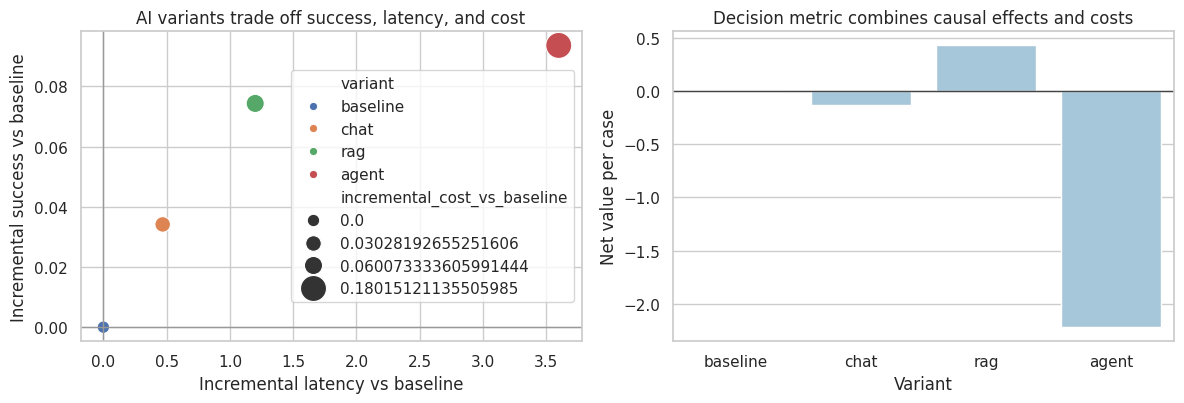

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
decision_plot = decision_table.reset_index(names="variant")

sns.scatterplot(
    data=decision_plot,
    x="incremental_latency_vs_baseline",
    y="incremental_success_vs_baseline",
    size="incremental_cost_vs_baseline",
    hue="variant",
    sizes=(80, 350),
    ax=axes[0],
)
axes[0].axhline(0, color="#999999", linewidth=1)
axes[0].axvline(0, color="#999999", linewidth=1)
axes[0].set_title("AI variants trade off success, latency, and cost")
axes[0].set_xlabel("Incremental latency vs baseline")
axes[0].set_ylabel("Incremental success vs baseline")

sns.barplot(data=decision_plot, x="variant", y="net_value_per_case", ax=axes[1], color="#9ecae1")
axes[1].axhline(0, color="#444444", linewidth=1)
axes[1].set_title("Decision metric combines causal effects and costs")
axes[1].set_xlabel("Variant")
axes[1].set_ylabel("Net value per case")

plt.tight_layout()
plt.show()


The "best" system depends on the decision objective. A tool-using agent may have the highest success rate but not the highest net value if latency, cost, and bad-output risk are expensive.

AI evaluations depend on treatment definition, logging, measurement quality, and downstream behavior, more than model output alone.

## 6. RAG as a Causal System

Retrieval-augmented generation changes the causal pathway.

One simplified structure:

$$
RAG \rightarrow RetrievalHit \rightarrow AnswerQuality \rightarrow Outcome
$$

but RAG can also affect latency, user trust, refusal behavior, and follow-up actions.

Retrieval quality is usually a mediator, not a baseline covariate. Conditioning on it answers a mechanism question, not the total deployment effect.


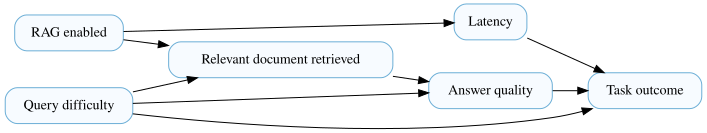

In [10]:
dot = Digraph("rag_dag", graph_attr={"rankdir": "LR"})
dot.attr("node", shape="box", style="rounded,filled", fillcolor="#f7fbff", color="#6baed6")

dot.node("A", "RAG enabled")
dot.node("X", "Query difficulty")
dot.node("Hit", "Relevant document retrieved")
dot.node("Quality", "Answer quality")
dot.node("Latency", "Latency")
dot.node("Outcome", "Task outcome")

dot.edge("X", "Hit")
dot.edge("X", "Quality")
dot.edge("X", "Outcome")
dot.edge("A", "Hit")
dot.edge("A", "Latency")
dot.edge("Hit", "Quality")
dot.edge("Quality", "Outcome")
dot.edge("Latency", "Outcome")

dot


The point is to connect the number to the decision it supports. For AI systems, model output is only one layer of the causal system. Usage, routing, and measurement matter too.

In [11]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
rng = np.random.default_rng(5012)
n = 9000
rag = pd.DataFrame({"difficulty": rng.normal(0, 1, size=n)})
rag["rag_enabled"] = rng.binomial(1, 0.5, size=n)
rag["retrieval_hit"] = rng.binomial(
    1,
    expit(-0.4 + 1.4 * rag["rag_enabled"] - 0.7 * rag["difficulty"]),
    size=n,
)
rag["latency"] = 4.0 + 1.3 * rag["rag_enabled"] + 0.8 * rag["difficulty"] + rng.normal(0, 0.8, size=n)
rag["quality"] = (
    3.2
    + 0.25 * rag["rag_enabled"]
    + 1.1 * rag["retrieval_hit"]
    - 0.6 * rag["difficulty"]
    + rng.normal(0, 0.9, size=n)
)
rag["task_success"] = rng.binomial(
    1,
    expit(-1.0 + 0.8 * rag["quality"] - 0.18 * rag["latency"] - 0.35 * rag["difficulty"]),
    size=n,
)

total_effect = mean_difference(rag, "task_success", "rag_enabled")
adjust_for_mediator = smf.ols(
    "task_success ~ rag_enabled + retrieval_hit + latency + difficulty",
    data=rag,
).fit()
diagnostic_model = smf.ols("quality ~ rag_enabled + retrieval_hit + difficulty", data=rag).fit()

rag_results = pd.DataFrame(
    {
        "Total effect: RAG assignment": total_effect,
        "Controlled direct-style coefficient after mediators": regression_effect(adjust_for_mediator, "rag_enabled"),
        "Effect on answer quality controlling retrieval": regression_effect(diagnostic_model, "rag_enabled"),
    }
).T

rag_results


,estimate,std_error,ci_lower,ci_upper,p_value
Total effect: RAG assignment,0.0319,0.0094,0.0135,0.0503,NaN
Controlled direct-style coefficient after mediators,0.0258,0.0114,0.0035,0.0482,0.0236
Effect on answer quality controlling retrieval,0.2303,0.0199,0.1913,0.2693,0.0000


The total effect is the clean deployment estimand under randomization. The mediator-adjusted coefficient is not "more correct"; it answers a different question: how much difference remains after controlling retrieval and latency.

For RAG projects, report both:

- total effect on decision metrics,
- mechanism diagnostics such as retrieval hit rate, answer quality, citation correctness, latency, and refusal behavior.


## 7. LLM-as-Judge Is a Measurement System

LLM judges can be useful for scalable evaluation, but they are not ground truth. Zheng et al. (2023) study LLM-as-judge evaluation and discuss biases such as position and verbosity effects.

In causal terms, the judge creates a measured outcome:

$$
Y^\ast = \text{JudgeScore}
$$

which may differ from the target construct:

$$
Y = \text{Human-valued quality}
$$

If judge bias differs by treatment, the measured treatment effect can be biased.


In [12]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
rng = np.random.default_rng(5013)
n = 7000
judge = pd.DataFrame({"prompt_difficulty": rng.normal(0, 1, size=n)})
judge["new_model"] = rng.binomial(1, 0.5, size=n)
judge["verbosity"] = rng.normal(0, 1, size=n) + 0.75 * judge["new_model"]

true_quality_effect = 0.32
judge["human_quality"] = (
    4.0
    + true_quality_effect * judge["new_model"]
    - 0.55 * judge["prompt_difficulty"]
    + rng.normal(0, 0.9, size=n)
)

judge["llm_judge_score"] = (
    judge["human_quality"]
    + 0.38 * judge["verbosity"]
    + 0.10 * judge["new_model"]
    + rng.normal(0, 0.75, size=n)
)

human_effect = mean_difference(judge, "human_quality", "new_model")
judge_effect = mean_difference(judge, "llm_judge_score", "new_model")

measurement_results = pd.DataFrame(
    {
        "Human audit quality effect": human_effect,
        "Raw LLM-judge score effect": judge_effect,
    }
).T

measurement_results


,estimate,std_error,ci_lower,ci_upper,p_value
Human audit quality effect,0.3600,0.0252,0.3107,0.4093,NaN
Raw LLM-judge score effect,0.7283,0.0320,0.6656,0.7910,NaN


Here the example becomes operational. The evaluation is credible when the product intervention, the logging, and the outcome measurement are all explicit.

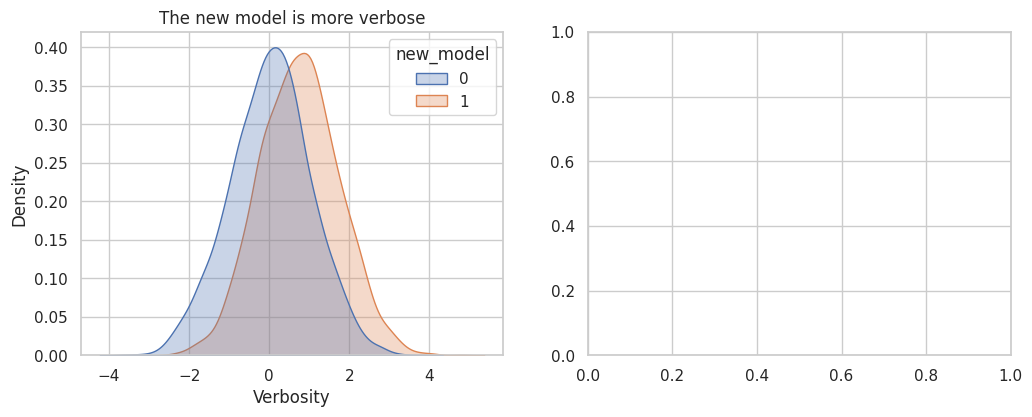

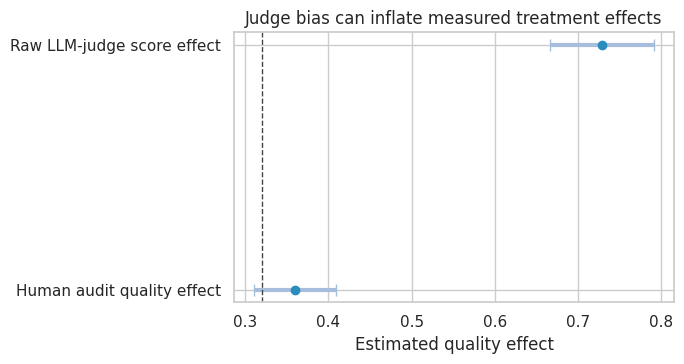

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.kdeplot(data=judge, x="verbosity", hue="new_model", fill=True, common_norm=False, alpha=0.30, ax=axes[0])
axes[0].set_title("The new model is more verbose")
axes[0].set_xlabel("Verbosity")

plot_coef_table(
    measurement_results,
    title="Judge bias can inflate measured treatment effects",
    xlabel="Estimated quality effect",
    reference=true_quality_effect,
    figsize=(7, 3.8),
)
plt.show()


This output should make the next modeling choice easier to defend. AI evaluations depend on treatment definition, logging, measurement quality, and downstream behavior.

### Calibration with Human Audit Data

A practical approach is to audit a sample with human labels and calibrate the judge score. Human-label calibration cannot make the judge perfect. It can reduce systematic measurement bias.


In [14]:
audit = judge.sample(900, random_state=41).copy()
calibration = smf.ols(
    "human_quality ~ llm_judge_score + verbosity + prompt_difficulty + new_model",
    data=audit,
).fit()

judge["calibrated_quality"] = calibration.predict(judge)
calibrated_effect = mean_difference(judge, "calibrated_quality", "new_model")

measurement_results.loc["Calibrated judge using human audit"] = calibrated_effect
measurement_results


,estimate,std_error,ci_lower,ci_upper,p_value
Human audit quality effect,0.3600,0.0252,0.3107,0.4093,NaN
Raw LLM-judge score effect,0.7283,0.0320,0.6656,0.7910,NaN
Calibrated judge using human audit,0.3499,0.0213,0.3082,0.3916,NaN


The result is most useful when it shapes the next action. For AI systems, model output is only one layer of the causal system. Usage, routing, and measurement matter too.

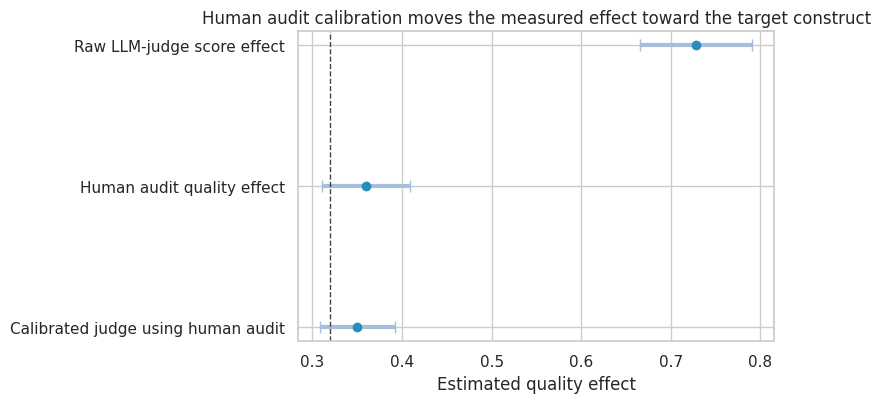

In [15]:
plot_coef_table(
    measurement_results,
    title="Human audit calibration moves the measured effect toward the target construct",
    xlabel="Estimated quality effect",
    reference=true_quality_effect,
    figsize=(8, 4.2),
)
plt.show()


A credible LLM evaluation stack should separate:

- target construct,
- automated judge,
- human audit,
- calibration model,
- known judge biases,
- uncertainty from measurement.

This is measurement error, not just "evaluation tooling."


## 8. Adaptive AI Routing and Logged Policy Evaluation

Many AI systems route requests:

- small model for easy tasks,
- large model for hard tasks,
- human escalation for risky tasks.

Historical logs are confounded because the action was chosen based on context. We observe only the reward for the action actually taken.

This is a contextual bandit problem. To evaluate a new policy offline, we need logged propensities or strong modeling assumptions.


In [16]:
# Define reusable helpers so the later analytical cells stay focused on the causal argument.
rng = np.random.default_rng(5014)
n = 25_000
actions = np.array(["small_model", "large_model", "human"])

logged = pd.DataFrame(
    {
        "difficulty": rng.normal(0, 1, size=n),
        "risk": rng.normal(0, 1, size=n),
        "customer_value": rng.lognormal(1.4, 0.7, size=n),
    }
)

def softmax(logits):
    """Compute softmax for the causal inference with llm ai systems example.
    
    Inputs:
    - `logits`: unscaled action scores converted into probabilities by softmax.
    Returns: row-normalized action probabilities."""
    z = logits - logits.max(axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / exp_z.sum(axis=1, keepdims=True)


logits = np.column_stack(
    [
        1.2 - 1.1 * logged["difficulty"] - 0.8 * logged["risk"],
        0.2 + 0.5 * logged["difficulty"] + 0.1 * logged["risk"],
        -0.9 + 0.8 * logged["difficulty"] + 1.2 * logged["risk"],
    ]
)
propensities = softmax(logits)
action_idx = np.array([rng.choice(3, p=p) for p in propensities])
logged["action"] = actions[action_idx]
for j, action in enumerate(actions):
    logged[f"p_logged_{action}"] = propensities[:, j]
logged["p_logged_action"] = propensities[np.arange(n), action_idx]

def potential_reward(df, action):
    """Compute simulated potential rewards for an AI routing action.
    
    Inputs:
    - `df`: pandas DataFrame containing the observed or simulated data used by this estimator, plot, or diagnostic.
    - `action`: single action whose potential reward is being computed.
    Returns: a NumPy array of rewards each request would receive under the specified action."""
    difficulty = df["difficulty"].to_numpy()
    risk = df["risk"].to_numpy()
    value = df["customer_value"].to_numpy()
    if action == "small_model":
        success_p = expit(1.0 - 1.2 * difficulty - 1.0 * risk)
        cost = 0.03
    elif action == "large_model":
        success_p = expit(1.3 - 0.55 * difficulty - 0.55 * risk)
        cost = 0.18
    else:
        success_p = expit(1.7 - 0.25 * difficulty - 0.25 * risk)
        cost = 2.50
    return 10 * success_p + 0.35 * value * success_p - cost


for action in actions:
    logged[f"reward_{action}"] = potential_reward(logged, action)

logged["expected_reward"] = logged[[f"reward_{a}" for a in actions]].to_numpy()[np.arange(n), action_idx]
logged["reward"] = logged["expected_reward"] + rng.normal(0, 1.2, size=n)

logged[["difficulty", "risk", "action", "p_logged_action", "reward"]].head()


,difficulty,risk,action,p_logged_action,reward
0,1.3805,-0.7148,large_model,0.5563,7.7807
1,-0.2331,-0.4028,small_model,0.8255,7.2032
2,0.4672,2.0845,human,0.7601,8.2482
3,0.6359,0.0986,human,0.1912,5.1430
4,1.1025,0.6369,large_model,0.4553,6.5559


Suppose the new policy is:

- use the small model for easy and low-risk requests,
- use the large model for moderately hard requests,
- escalate to human for high-risk requests.

AI evaluations depend on treatment definition, logging, measurement quality, and downstream behavior, more than model output alone.

In [17]:
# Fit the models for this section and assemble the estimates used in the discussion.
def new_policy_action(df):
    """Apply the proposed AI routing policy to each request.
    
    Inputs:
    - `df`: pandas DataFrame containing the observed or simulated data used by this estimator, plot, or diagnostic.
    Returns: an array assigning each row to small model, large model, or human escalation."""
    return np.select(
        [
            (df["risk"] > 1.0) | (df["difficulty"] > 1.4),
            df["difficulty"] > -0.3,
        ],
        ["human", "large_model"],
        default="small_model",
    )


logged["new_policy_action"] = new_policy_action(logged)
logged["matches_new_policy"] = (logged["action"] == logged["new_policy_action"]).astype(int)
logged["p_logged_new_action"] = [
    row[f"p_logged_{row['new_policy_action']}"] for _, row in logged.iterrows()
]

true_policy_value = np.mean(
    [
        logged.loc[i, f"reward_{logged.loc[i, 'new_policy_action']}"]
        for i in logged.index
    ]
)
logged_policy_value = logged["reward"].mean()

ips_value = np.mean(logged["matches_new_policy"] * logged["reward"] / logged["p_logged_action"])
self_normalized_ips = (
    (logged["matches_new_policy"] * logged["reward"] / logged["p_logged_action"]).sum()
    / (logged["matches_new_policy"] / logged["p_logged_action"]).sum()
)

direct_models = {}
for action in actions:
    part = logged.loc[logged["action"] == action]
    direct_models[action] = smf.ols("reward ~ difficulty + risk + np.log1p(customer_value)", data=part).fit()

for action in actions:
    logged[f"mhat_{action}"] = direct_models[action].predict(logged)

logged["mhat_new_policy"] = [
    logged.loc[i, f"mhat_{logged.loc[i, 'new_policy_action']}"]
    for i in logged.index
]
logged["mhat_logged_action"] = [
    logged.loc[i, f"mhat_{logged.loc[i, 'action']}"]
    for i in logged.index
]

direct_method_value = logged["mhat_new_policy"].mean()
dr_value = (
    logged["mhat_new_policy"]
    + logged["matches_new_policy"] * (logged["reward"] - logged["mhat_logged_action"]) / logged["p_logged_action"]
).mean()

policy_eval = pd.DataFrame(
    [
        {"method": "True new policy value in simulation", "value": true_policy_value},
        {"method": "Current logged policy value", "value": logged_policy_value},
        {"method": "IPS estimate", "value": ips_value},
        {"method": "Self-normalized IPS estimate", "value": self_normalized_ips},
        {"method": "Direct reward-model estimate", "value": direct_method_value},
        {"method": "Doubly robust estimate", "value": dr_value},
    ]
)
policy_eval["error_vs_true_new_policy"] = policy_eval["value"] - true_policy_value
policy_eval


,method,value,error_vs_true_new_policy
0,True new policy value in simulation,8.8881,0.0000
1,Current logged policy value,8.6607,-0.2274
2,IPS estimate,8.8645,-0.0236
3,Self-normalized IPS estimate,8.8558,-0.0323
4,Direct reward-model estimate,8.8466,-0.0415
5,Doubly robust estimate,8.8494,-0.0387


This is a checkpoint for the design and the estimate together. The evaluation is credible when the product intervention, the logging, and the outcome measurement are all explicit.

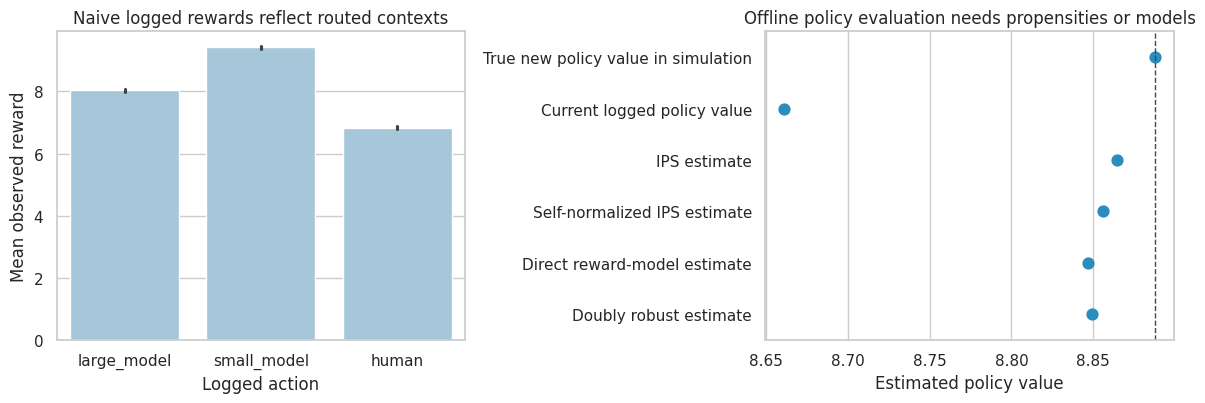

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.barplot(data=logged, x="action", y="reward", ax=axes[0], color="#9ecae1")
axes[0].set_title("Naive logged rewards reflect routed contexts")
axes[0].set_xlabel("Logged action")
axes[0].set_ylabel("Mean observed reward")

sns.pointplot(data=policy_eval, y="method", x="value", join=False, ax=axes[1], color="#2b8cbe")
axes[1].axvline(true_policy_value, color="#444444", linestyle="--", linewidth=1)
axes[1].set_title("Offline policy evaluation needs propensities or models")
axes[1].set_xlabel("Estimated policy value")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


### Interpretation

The naive action comparison is not a causal comparison. Human escalation handles harder and riskier requests, so its raw reward is not directly comparable to the small model's reward.

IPS uses the logged propensity to reweight cases where the historical action matches the new policy. Doubly robust evaluation combines a reward model with propensity correction. This is directly relevant to LLM routing, recommender systems, ad systems, and AI triage.


## 9. Feedback Loops in AI Systems

AI systems change the data they later learn from.

Examples:

- a recommender changes what users click,
- an AI support bot changes which tickets humans label,
- a fraud model changes attacker behavior,
- an AI search answer reduces clicks to source documents,
- an agent changes which tool traces appear in logs.

Sculley et al. (2015) discuss hidden feedback loops as a technical-debt risk in ML systems. Bottou et al. (2013) frame complex learning systems as systems that interact with their environment and require counterfactual reasoning.


In [19]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
rng = np.random.default_rng(5015)
periods = 16
rows = []
training_mean_difficulty = 0.0
model_strength = 0.0

for t in range(periods):
    # Population difficulty is stable, but observed labeled data depends on the deployed model.
    population_difficulty = rng.normal(0, 1, size=6000)
    success_prob = expit(0.8 + model_strength - 0.9 * population_difficulty)
    served = rng.binomial(1, success_prob)
    labeled = population_difficulty[served == 1]
    
    rows.append(
        {
            "period": t,
            "model_strength": model_strength,
            "population_mean_difficulty": population_difficulty.mean(),
            "labeled_mean_difficulty": labeled.mean(),
            "served_rate": served.mean(),
            "labeled_n": len(labeled),
        }
    )
    
    # Retraining on easier observed successes makes the system look better on logs but can narrow coverage.
    if len(labeled) > 0:
        training_mean_difficulty = 0.75 * training_mean_difficulty + 0.25 * labeled.mean()
    model_strength = 0.2 - 0.35 * training_mean_difficulty

feedback = pd.DataFrame(rows)
feedback


,period,model_strength,population_mean_difficulty,labeled_mean_difficulty,served_rate,labeled_n
0,0,0.0000,0.0075,-0.2453,0.6672,4003
1,1,0.2215,0.0144,-0.2088,0.7108,4265
2,2,0.2344,0.0038,-0.2265,0.7072,4243
3,3,0.2456,-0.0072,-0.2621,0.7008,4205
4,4,0.2571,0.0076,-0.2184,0.7013,4208
5,5,0.2620,-0.0068,-0.2356,0.7162,4297
6,6,0.2671,0.0159,-0.2176,0.7112,4267
7,7,0.2694,-0.0060,-0.2268,0.7192,4315
8,8,0.2719,0.0184,-0.2212,0.7068,4241
9,9,0.2733,-0.0075,-0.2278,0.7217,4330


The result matters because it changes what we would audit or do next. AI evaluations depend on treatment definition, logging, measurement quality, and downstream behavior.

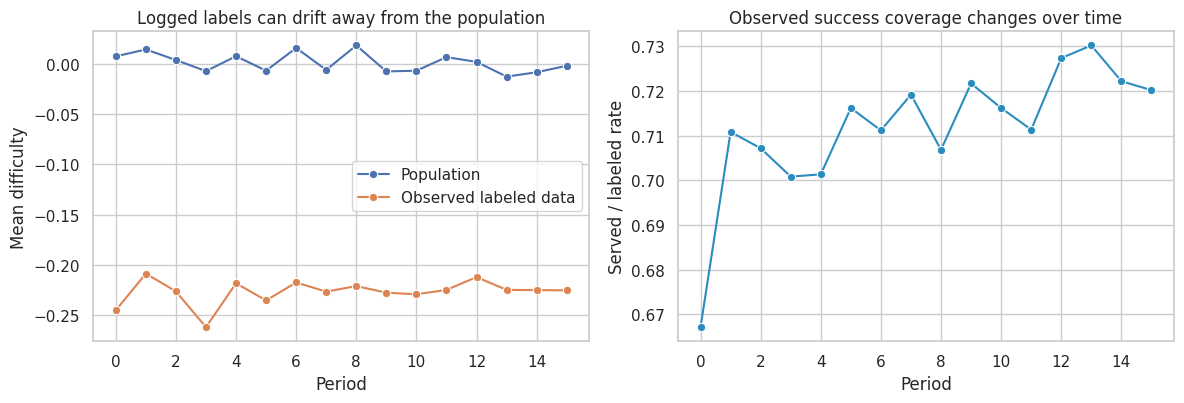

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.lineplot(data=feedback, x="period", y="population_mean_difficulty", marker="o", ax=axes[0], label="Population")
sns.lineplot(data=feedback, x="period", y="labeled_mean_difficulty", marker="o", ax=axes[0], label="Observed labeled data")
axes[0].set_title("Logged labels can drift away from the population")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Mean difficulty")

sns.lineplot(data=feedback, x="period", y="served_rate", marker="o", ax=axes[1], color="#2b8cbe")
axes[1].set_title("Observed success coverage changes over time")
axes[1].set_xlabel("Period")
axes[1].set_ylabel("Served / labeled rate")

plt.tight_layout()
plt.show()


Feedback loops are a causal problem because the system changes the data-generating process. Monitoring should include:

- population-denominator metrics, not only served-case metrics,
- holdout or shadow-evaluation sets,
- randomized exploration where safe,
- logging propensities and routing decisions,
- drift checks for contexts, actions, and outcomes,
- downstream consumers of model outputs.


## 10. AI Experiment Design Patterns

The randomization unit should match the interference and deployment mechanism.


| AI setting | randomization unit | primary estimand | watch out for |
|---|---|---|---|
| User-facing assistant | User or account | Effect of assignment on task success and satisfaction | Users sharing outputs, learning over time, novelty effects |
| Support-agent copilot | Agent, ticket, team, or shift | Effect on resolution, handle time, quality, escalation | Team spillovers, agent learning, manager-level interventions |
| RAG search | User, query, session, or market | Effect on answer success, source visits, trust, latency | Query interference, source-click cannibalization, logging changes |
| Model routing | Request with logged routing propensities | Policy value under cost and quality constraints | Confounding by difficulty and adaptive routing |
| Agentic workflow | Task, user, or workflow instance | Effect on completed tasks, tool errors, cost, safety | Long-horizon failures and post-treatment tool traces |
| Recommendation or ranking | User, item cluster, query, market, or time block | Total marketplace or ecosystem effect | Interference and reallocation |


## 11. Guardrails and Harm Metrics

AI experiments should include primary success metrics and guardrail metrics.

For LLM systems, guardrails might include:

- unsafe output rate,
- hallucination or unsupported claim rate,
- false refusal rate,
- privacy leakage,
- user complaint rate,
- human escalation rate,
- latency,
- cost,
- downstream correction burden,
- demographic or language subgroup disparities.

The causal question is not only:

$$
E[\text{Success}(1) - \text{Success}(0)]
$$

but also:

$$
E[\text{Harm}(1) - \text{Harm}(0)]
$$


| metric | role | measurement | decision use |
|---|---|---|---|
| Task success | Primary benefit | Behavioral completion plus human audit | Launch requires positive effect above practical threshold. |
| Unsupported claim rate | Safety guardrail | Human audit calibrated automated judge | Must not increase beyond agreed tolerance. |
| False refusal rate | User experience guardrail | Human-labeled eligible requests | Track by task type and language. |
| Cost per resolved task | Operational guardrail | Model tokens, tool calls, human handoff cost | Compare net value, not only quality. |
| Latency | Experience guardrail | End-to-end p50, p95, p99 | Check tail latency for agent workflows. |
| Subgroup disparity | Fairness/reliability guardrail | Effect heterogeneity by language, region, device, account type | Escalate if benefits or harms concentrate. |


## 12. Monitoring After Launch

An AI launch is not the end of the causal problem. It is the start of a new data-generating regime.

Post-launch monitoring should track:

- whether the deployed population matches the experiment population,
- whether effects persist after novelty fades,
- whether users learn to rely on or game the system,
- whether model outputs feed future training data,
- whether cost and latency shift at production scale,
- whether safety metrics drift,
- whether new model versions change the estimand.


| monitoring layer | question | statistic |
|---|---|---|
| Population drift | Are current users/tasks like experiment users/tasks? | SMDs, propensity-to-be-experiment-like, traffic mix |
| Effect persistence | Does impact decay or grow over exposure time? | Cohort/event-time treatment effects |
| Measurement drift | Did labels, judges, logs, or metrics change? | Human audit agreement, judge calibration, logging completeness |
| Feedback loops | Does the model affect future training/evaluation data? | Denominator metrics and holdout/shadow sets |
| Policy change | Did routing, prompts, retrieval, model version, or tools change? | Versioned treatment registry and exposure logs |
| Safety and fairness | Do harms concentrate in specific segments? | Guardrail treatment effects by subgroup |


## 13. Industry Decision Memo Example

Here is a concise causal memo for an LLM assistant deployment.


In [24]:
# Fit the models for this section and assemble the estimates used in the discussion.
memo = f'''
### AI Deployment Causal Memo

**Decision.** Decide whether to launch a RAG-enabled support assistant to all agents.

**Intervention.** Assignment to the RAG assistant in the agent console. The assistant can retrieve policy documents and draft responses.

**Primary estimand.** Intent-to-treat effect of assignment on first-contact resolution among eligible support tickets.

**Secondary estimands.**

- Effect on handle time.
- Effect on unsupported-claim rate.
- Effect on human escalation.
- Heterogeneous effects by case complexity and agent experience.

**Design.**

- Randomize at the agent or team level to reduce learning spillovers.
- Keep model, prompt, retrieval index, and guardrails versioned during the experiment.
- Pre-register primary and guardrail metrics.
- Trigger analysis on tickets where the assistant could plausibly be used.

**Measurement plan.**

- Use behavioral outcomes for resolution and handle time.
- Use human audit data to calibrate automated LLM-judge quality scores.
- Report judge bias checks for verbosity, position, and model-version preference.

**Main risks.**

- Usage is post-treatment, so the primary estimate should be assignment-based ITT.
- Retrieval success is a mediator, not a baseline control.
- Team learning can contaminate controls.
- Logs generated by the assistant may feed future evaluation data.

**Decision rule.**

- Launch only if resolution improves, unsupported-claim rate does not exceed tolerance, and net value remains positive after model and review costs.
'''.strip()

display(Markdown(memo))


### AI Deployment Causal Memo

**Decision.** Decide whether to launch a RAG-enabled support assistant to all agents.

**Intervention.** Assignment to the RAG assistant in the agent console. The assistant can retrieve policy documents and draft responses.

**Primary estimand.** Intent-to-treat effect of assignment on first-contact resolution among eligible support tickets.

**Secondary estimands.**

- Effect on handle time.
- Effect on unsupported-claim rate.
- Effect on human escalation.
- Heterogeneous effects by case complexity and agent experience.

**Design.**

- Randomize at the agent or team level to reduce learning spillovers.
- Keep model, prompt, retrieval index, and guardrails versioned during the experiment.
- Pre-register primary and guardrail metrics.
- Trigger analysis on tickets where the assistant could plausibly be used.

**Measurement plan.**

- Use behavioral outcomes for resolution and handle time.
- Use human audit data to calibrate automated LLM-judge quality scores.
- Report judge bias checks for verbosity, position, and model-version preference.

**Main risks.**

- Usage is post-treatment, so the primary estimate should be assignment-based ITT.
- Retrieval success is a mediator, not a baseline control.
- Team learning can contaminate controls.
- Logs generated by the assistant may feed future evaluation data.

**Decision rule.**

- Launch only if resolution improves, unsupported-claim rate does not exceed tolerance, and net value remains positive after model and review costs.

## 14. Common Failure Modes

1. Treating benchmark wins as causal evidence of product impact.
2. Comparing users who used the AI system with users who did not, ignoring self-selection.
3. Conditioning on retrieval success, tool use, or handoff when estimating total deployment effect.
4. Letting an LLM judge define the outcome without human calibration.
5. Ignoring treatment versioning: model, prompt, retrieval index, tools, guardrails, and UI all matter.
6. Evaluating a new routing policy from logs without propensities.
7. Reporting average effects while hiding subgroup failures.
8. Measuring only served cases while the AI system changes who gets served.
9. Ignoring interference between users, agents, sellers, or documents.
10. Launching without post-deployment drift and feedback-loop monitoring.


## 15. Exercises

1. In the AI assistant simulation, make difficult cases more likely to use AI. How does the as-treated comparison change?
2. Estimate the ITT effect on `handle_minutes`. Does the AI assistant save time?
3. In the multi-arm experiment, change the net-value formula so latency is more expensive. Which variant wins?
4. In the RAG simulation, estimate the effect of RAG on retrieval hit rate and latency separately.
5. In the judge simulation, remove the human-audit calibration variable `verbosity`. How much bias remains?
6. In the logged-policy simulation, make the logging policy almost deterministic. What happens to IPS variance?
7. Design an experiment for an agentic workflow where failures may occur several steps after the first response.
8. Pick a real AI feature and write down the treatment version, randomization unit, primary estimand, guardrails, and monitoring plan.


## 16. Key Takeaways

- AI systems are interventions, not only predictors.
- Causal estimands must specify the model, prompt, retrieval, tools, UI, routing, and guardrail version being deployed.
- Randomized assignment identifies assignment effects; actual usage is often selected and post-treatment.
- LLM-as-judge evaluation is a measurement problem that needs human calibration and bias checks.
- RAG and agent traces often contain mediators, not baseline controls.
- Logged AI routing requires propensity-aware counterfactual evaluation.
- Feedback loops make production AI a changing causal system.
- The best AI deployment workflow combines experiments, causal diagnostics, measurement audits, guardrails, and post-launch monitoring.


## References

Amodei, D., Olah, C., Steinhardt, J., Christiano, P., Schulman, J., & Mané, D. (2016). Concrete problems in AI safety. *arXiv*. https://arxiv.org/abs/1606.06565

Bottou, L., Peters, J., Quiñonero-Candela, J., Charles, D. X., Chickering, D. M., Portugaly, E., Ray, D., Simard, P., & Snelson, E. (2013). Counterfactual reasoning and learning systems: The example of computational advertising. *Journal of Machine Learning Research, 14*, 3207-3260. https://jmlr.org/papers/v14/bottou13a.html

Dudík, M., Langford, J., & Li, L. (2011). Doubly robust policy evaluation and learning. *Proceedings of the 28th International Conference on Machine Learning*. https://icml.cc/2011/papers/554_icmlpaper.pdf

Kohavi, R., Tang, D., & Xu, Y. (2020). *Trustworthy online controlled experiments: A practical guide to A/B testing*. Cambridge University Press. https://doi.org/10.1017/9781108653985

Lewis, P., Perez, E., Piktus, A., Petroni, F., Karpukhin, V., Goyal, N., Küttler, H., Lewis, M., Yih, W., Rocktäschel, T., Riedel, S., & Kiela, D. (2020). Retrieval-augmented generation for knowledge-intensive NLP tasks. *Advances in Neural Information Processing Systems*. https://arxiv.org/abs/2005.11401

Sculley, D., Holt, G., Golovin, D., Davydov, E., Phillips, T., Ebner, D., Chaudhary, V., Young, M., Crespo, J.-F., & Dennison, D. (2015). Hidden technical debt in machine learning systems. *Advances in Neural Information Processing Systems*. https://papers.nips.cc/paper/5656-hidden-technical-debt-in-machine-learning-systems

Swaminathan, A., & Joachims, T. (2015). Counterfactual risk minimization: Learning from logged bandit feedback. *Proceedings of the 32nd International Conference on Machine Learning*, 814-823. https://proceedings.mlr.press/v37/swaminathan15.html

Zheng, L., Chiang, W.-L., Sheng, Y., Zhuang, S., Wu, Z., Zhuang, Y., Lin, Z., Li, Z., Li, D., Xing, E. P., Zhang, H., Gonzalez, J. E., & Stoica, I. (2023). Judging LLM-as-a-judge with MT-Bench and Chatbot Arena. *arXiv*. https://arxiv.org/abs/2306.05685
